#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from predict_loop_functions import predict_loop, noise_iterations, add_brain_region
from scipy.stats import linregress

In [2]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

#### testing

In [3]:
test1, test2, test3 = predict_loop('dynamic', image_stack, 3, [[4,7]], noise_seeds = 3, num_frames = 1)

In [4]:
test4, test5, test6 = predict_loop('constant', image_stack, 25, [[4,7]], noise_seeds = 3, num_frames = 1)

#### predictions

In [3]:
d3_sum, d3_mean, d3_var = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [4]:
d15_sum, d15_mean, d15_var = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [5]:
d30_sum, d30_mean, d30_var = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [ ]:
c3_sum, c3_mean, c3_var = predict_loop('constant', image_stack, 3, [[4,7]])

In [7]:
c15_sum, c15_mean, c15_var = predict_loop('constant', image_stack, 15, [[4,7]])

In [8]:
c30_sum, c30_mean, c30_var = predict_loop('constant', image_stack, 30, [[4,7]])

In [10]:
dbin_sum, dbin_mean, dbin_var = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [9]:
cbin_sum, cbin_mean, cbin_var = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

saving predictions to july 18 folder in saved_inputs_outputs

In [20]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30']:
    for type in ['_sum', '_mean', '_var']:
        file_name = noise + type
        path = 'saved_inputs_outputs//predictions_july18//' + file_name
        np.save(path, arr = globals()[file_name])

In [21]:
for noise in ['dbin', 'cbin']:
    for func in ['_sum', '_mean', '_var']:
        file_name = noise + func
        path = 'saved_inputs_outputs//predictions_july18//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions from folder

In [3]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30']:
    for type in ['_sum', '_mean', '_var']:
        file_name = noise + type + '.npy'
        var_name = noise + type
        path = 'saved_inputs_outputs//predictions_july18//' + file_name
        globals()[var_name] = np.load(path)

#### sigma against mean

In [7]:
def line_plot_mean(array, neurons):
    array = array[:,:,:-1]
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        avg = np.mean(np.sum(array[:,:,neuron], axis = 1))
        final_array[i] = avg
    return final_array

In [8]:
mean_d30 = line_plot_mean(d30_sum, [i for i in range(100)])
mean_d15 = line_plot_mean(d15_sum, [i for i in range(100)])
mean_d3 = line_plot_mean(d3_sum, [i for i in range(100)])
mean_c30 = line_plot_mean(c30_sum, [i for i in range(100)])
mean_c15 = line_plot_mean(c15_sum, [i for i in range(100)])
mean_c3 = line_plot_mean(c3_sum, [i for i in range(100)])

In [9]:
mean_c15.shape

(100,)

In [10]:
min(mean_c15)

np.float64(805.0948444988578)

In [11]:
np.mean(mean_d30)

np.float64(1350.0401470006784)

C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\2078862445.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\2078862445.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


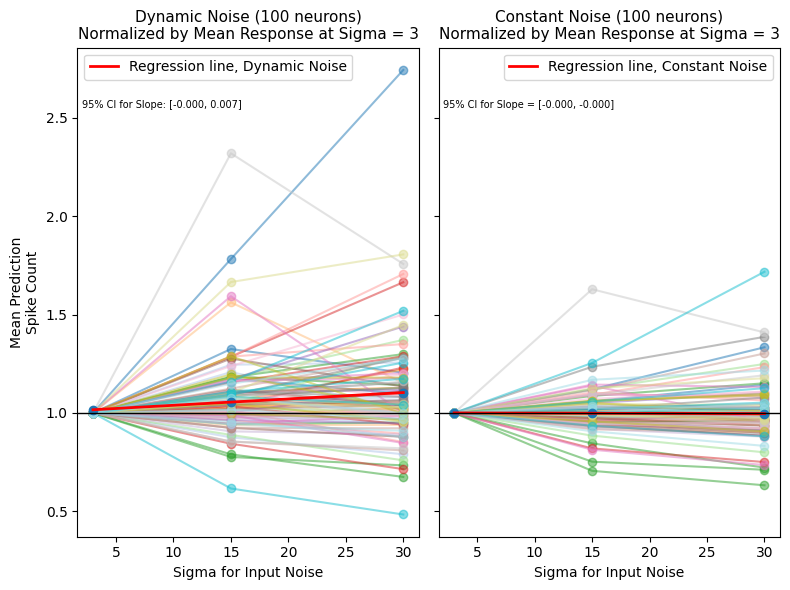

In [16]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]] / mean_c3[i]
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]] / mean_d3[i]

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(mean_d3)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(mean_c3)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 2.55, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 2.55, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Mean Response at Sigma = 3', fontsize = 11)
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Mean Response at Sigma = 3', fontsize = 11)
axes[0].set_ylabel('Mean Prediction\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\2992686199.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\2992686199.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


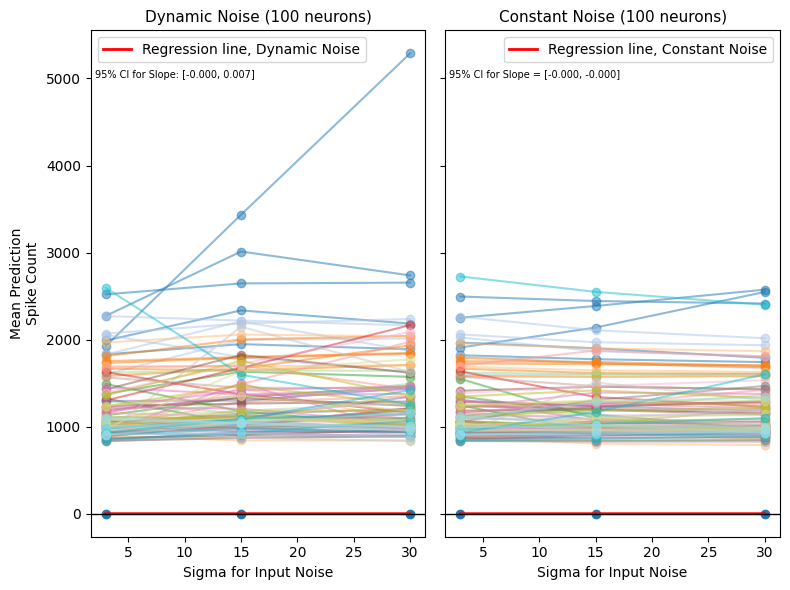

In [22]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_means = [mean_d3, mean_d15, mean_d30] 
constant_means = [mean_c3, mean_c15, mean_c30] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [mean_c3[i], mean_c15[i], mean_c30[i]] 
    dynamic_y = [mean_d3[i], mean_d15[i], mean_d30[i]] 
    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(mean_d3)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(mean_c3)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 5000, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 5000, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)', fontsize = 11)
axes[1].set_title('Constant Noise (100 neurons)', fontsize = 11)
axes[0].set_ylabel('Mean Prediction\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

#### sigma against variance

In [23]:
def line_plot_var(array, neurons):
    array = array[:,:,:-1]
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        avg = np.var(np.sum(array[:,:,neuron], axis = 1))
        final_array[i] = avg
    return final_array

In [25]:
d30var = line_plot_var(d30_sum, [i for i in range(100)])
d15var = line_plot_var(d15_sum, [i for i in range(100)])
d3var = line_plot_var(d3_sum, [i for i in range(100)])
c30var = line_plot_var(c30_sum, [i for i in range(100)])
c15var = line_plot_var(c15_sum, [i for i in range(100)])
c3var = line_plot_var(c3_sum, [i for i in range(100)])

C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\3291454679.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\3291454679.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


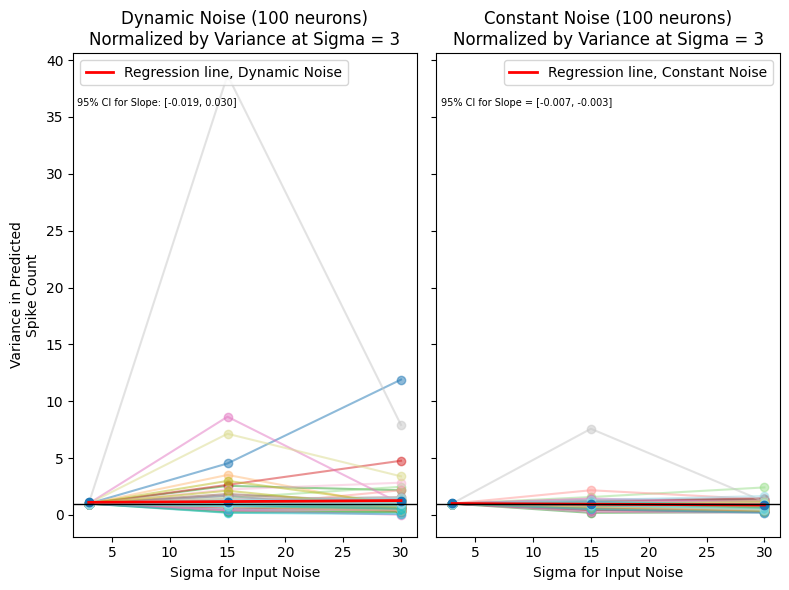

In [62]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_var = [d3var, d15var, d30var] 
constant_var = [c3var, c15var, c30var] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [c3var[i], c15var[i], c30var[i]] / c3var[i]
    dynamic_y = [d3var[i], d15var[i], d30var[i]] / d3var[i]

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_var, axis=1) / np.mean(d3var)  
constant_mean_y = np.mean(constant_var, axis=1) / np.mean(c3var)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 36, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 36, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Variance at Sigma = 3')
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Variance at Sigma = 3')
axes[0].set_ylabel('Variance in Predicted\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend(loc = 'upper left')
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\1237757635.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_55248\1237757635.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


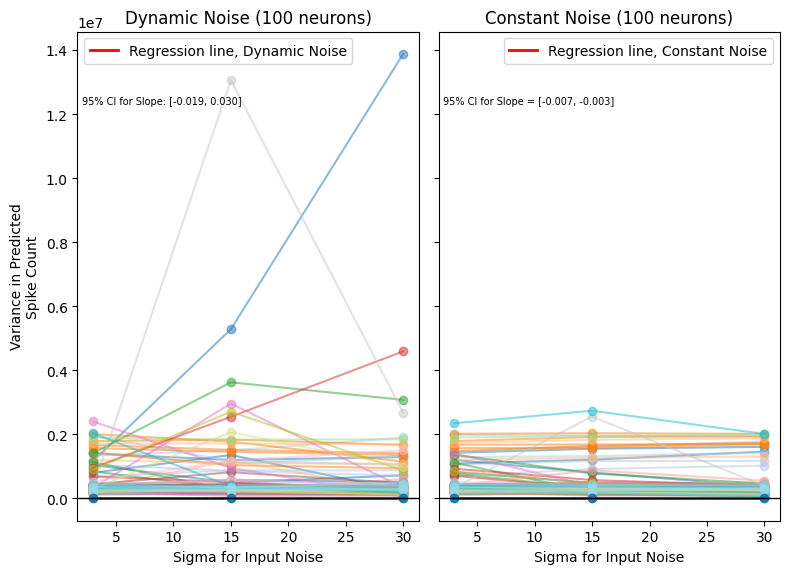

In [57]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30])

dynamic_var = [d3var, d15var, d30var] 
constant_var = [c3var, c15var, c30var] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    constant_y = [c3var[i], c15var[i], c30var[i]] 
    dynamic_y = [d3var[i], d15var[i], d30var[i]] 

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_var, axis=1) / np.mean(d3var)  
constant_mean_y = np.mean(constant_var, axis=1) / np.mean(c3var)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 12300000, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 12300000, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)')
axes[1].set_title('Constant Noise (100 neurons)')
axes[0].set_ylabel('Variance in Predicted\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend(loc = 'upper left')
axes[1].legend()
plt.tight_layout()
plt.show()

#### turning curves

In [4]:
# turning curve func. is for a single predicted array
def turning_curve(array, title, ten_neurons):
    # note input array should be sum object, ie first from prediction output
    array = array[:,:,:,-1]
    fix, ax = plt.subplots(1,1, figsize = (8,6))
    
    mean_array = np.mean(array, axis = 1)
    image_ids = np.array([i for i in range(5)], dtype = int)
    
    # error bar
    variance = np.var(array, axis = 1)
    std_dev = np.sqrt(variance)
    
    for neuron in ten_neurons:
        neuron_predictions = mean_array[:, neuron]
        plt.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron], marker = 'o', linestyle = '-', capsize=5)
    
    plt.title(f"Turning Curve for Imagenet Images\n{title}")
    plt.xlabel("Image ID")
    plt.ylabel('Mean Predicted Spike Count')

    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.grid()
    plt.tight_layout()
    plt.show()



In [5]:
c3_sum.shape

(5, 100, 7493, 2)

In [6]:
c3_sum[:,:,:,-1].shape

(5, 100, 7493)

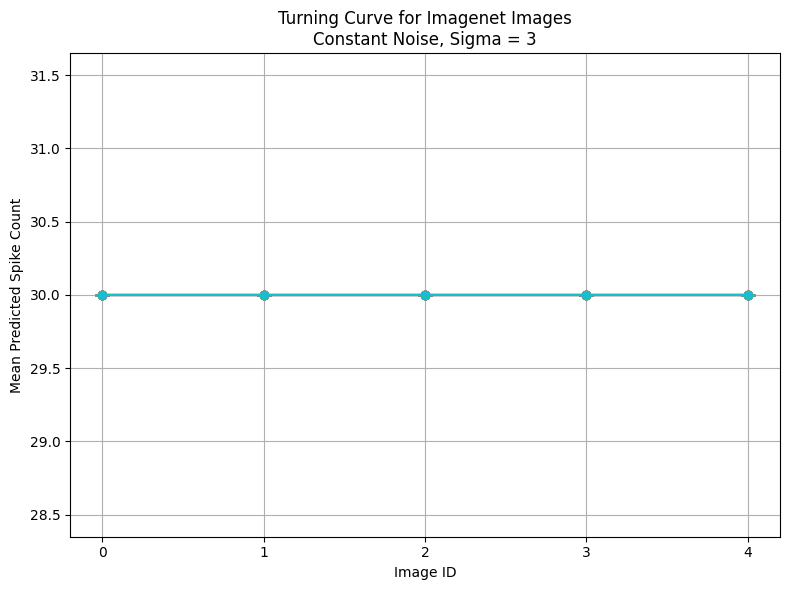

In [7]:
turning_curve(c3_sum, "Constant Noise, Sigma = 3", [i for i in range(10)])